# Conversion Rate vs. Contact Metrics by CDP

This notebook analyzes the relationship between conversion rates and various contact metrics, grouped by CDP (Customer Direct Program).

**Charts included:**
1. **Top 10 CDPs by Lead Volume** - Bar chart with conversion rate stars and data table
2. Conversion Rate vs. % Under 30 Minutes Contact
3. Conversion Rate vs. % Counter Contact
4. Conversion Rate vs. % No Contact
5. Conversion Rate vs. % Under 1 Hour Contact

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load data
file_path = '../data/raw/Conversion Data Nov-Dec 2025 (1).xlsx'
df = pd.read_excel(file_path, engine='openpyxl')

# Clean column names
df.columns = df.columns.str.strip()

print(f"Total records: {len(df):,}")
df.head()

Total records: 68,360


,CONFIRM_NUM,RENTER_LAST,CLAIM,CDP,CDP NAME,Week Of,INIT_DATE,4 loC,HTZREGION,SET_STATE,...,KNUM,MONTH,ZIP,CANCEL REASON,INIT_DT_FINAL,DT_FROM_ALPHA1,DAY_DIF,HRS_DIF,MIN_DIF,MMR
0,242-9890118,ROBINSON,115845,1856933,MULLINAX FORD OF OSCEOLA,2025-11-10,2025-11-13,NaN,LICENSEE,AL,...,N11491616,202511,36303,,2025-11-13 07:48:00,NaT,NaN,NaN,NaN,NO MMR
1,037-9938451,BETTINGFIELD,161742,0,,2025-11-10,2025-11-14,NaN,EASTERN,GA,...,037-9938451,202511,30518,NO SHOW,2025-11-14 08:30:00,NaT,NaN,NaN,NaN,NO MMR
2,037-9911253,PERRY,300-0674073-2025-PD-11,0,,2025-11-03,2025-11-04,NaN,EASTERN,GA,...,037-9911253,202511,30012,,2025-11-04 08:46:00,2025-11-04 08:58:00,0.0,0.0,12.0,NO MMR
3,037-9965736,JACKACKI,827423GQ,0,,2025-11-24,2025-11-25,NaN,CENTRAL,OH,...,037-9965736,202511,44146,,2025-11-25 11:02:00,NaT,NaN,NaN,NaN,NO MMR
4,037-9928472,JONES,300-0662001-2025,0,,2025-11-10,2025-11-10,NaN,EASTERN,SC,...,037-9928472,202511,29730,,2025-11-10 17:04:00,2025-11-10 17:05:00,0.0,0.0,1.0,NO MMR


In [3]:
# Check contact time and group distributions
print("CONTACT RANGE Distribution:")
print(df['CONTACT RANGE'].value_counts())
print("\nCONTACT_GROUP Distribution:")
print(df['CONTACT_GROUP'].value_counts())

CONTACT RANGE Distribution:
CONTACT RANGE
(a)<30min         18078
(b)31min - 1hr    17689
(c)1-3 hrs        12279
NO CONTACT         7413
(f)12-24 hrs       6719
(d)3-6 hrs         2496
(g)24-48 hrs       1543
(e)6-12 hrs        1491
(h)48+ hrs          652
Name: count, dtype: int64

CONTACT_GROUP Distribution:
CONTACT_GROUP
COUNTER       35663
HRD - OKC     25284
NO CONTACT     7413
Name: count, dtype: int64


In [4]:
# Calculate metrics by CDP
cdp_stats = df.groupby('CDP NAME').agg(
    total_reservations=('RES_ID', 'sum'),
    conversions=('RENT_IND', 'sum'),
    under_30min_count=('CONTACT RANGE', lambda x: (x == '(a)<30min').sum()),
    under_1hr_count=('CONTACT RANGE', lambda x: (x.isin(['(a)<30min', '(b)31min - 1hr'])).sum()),
    no_contact_count=('CONTACT RANGE', lambda x: (x == 'NO CONTACT').sum()),
    counter_count=('CONTACT_GROUP', lambda x: (x == 'COUNTER').sum()),
    total_contacts=('CONTACT RANGE', 'count')
).reset_index()

# Calculate rates
cdp_stats['conversion_rate'] = (cdp_stats['conversions'] / cdp_stats['total_reservations'] * 100)
cdp_stats['pct_under_30min'] = (cdp_stats['under_30min_count'] / cdp_stats['total_contacts'] * 100)
cdp_stats['pct_under_1hr'] = (cdp_stats['under_1hr_count'] / cdp_stats['total_contacts'] * 100)
cdp_stats['pct_no_contact'] = (cdp_stats['no_contact_count'] / cdp_stats['total_contacts'] * 100)
cdp_stats['pct_counter'] = (cdp_stats['counter_count'] / cdp_stats['total_contacts'] * 100)

# Filter to CDPs with meaningful volume (at least 50 reservations)
cdp_stats_filtered = cdp_stats[cdp_stats['total_reservations'] >= 50].copy()

print(f"Total CDPs: {len(cdp_stats)}")
print(f"CDPs with 50+ reservations: {len(cdp_stats_filtered)}")

cdp_stats_filtered.sort_values('total_reservations', ascending=False).head(15)

Total CDPs: 644
CDPs with 50+ reservations: 98


,CDP NAME,total_reservations,conversions,under_30min_count,under_1hr_count,no_contact_count,counter_count,total_contacts,conversion_rate,pct_under_30min,pct_under_1hr,pct_no_contact,pct_counter
592,STATE FARM-DULUTH HIRS,19419,10710,5619,10827,3212,8777,19419,55.152171,28.935579,55.754673,16.540502,45.198002
598,STATE FARM-TEMPE HIRS,16271,9403,3881,9281,1514,7239,16271,57.789933,23.852252,57.040133,9.304898,44.490197
116,COMMERCE INS-WEBSTER HIRS,3030,1809,551,995,107,1444,3030,59.702970,18.184818,32.838284,3.531353,47.656766
591,STATE FARM-DALLAS HIRS,2503,1858,778,1601,151,1246,2503,74.230923,31.082701,63.963244,6.032761,49.780264
604,TESLA INSURANCE CLAIMS,1931,1271,451,935,66,1262,1931,65.820818,23.355774,48.420508,3.417918,65.354738
587,STATE FARM-BLOOMINGTON HIRS,1631,1123,517,1040,138,818,1631,68.853464,31.698345,63.764562,8.461067,50.153280
120,COOPERATORS (CGIC) HIRS,1279,538,467,771,39,1240,1279,42.064113,36.512901,60.281470,3.049257,96.950743
136,ELEPHANT INS-GLEN ALLEN HIRS,637,482,151,352,24,363,637,75.667190,23.704867,55.259027,3.767661,56.985871
191,FIRST ACCEPT-NASHVLL HIRS,550,391,158,279,77,324,550,71.090909,28.727273,50.727273,14.000000,58.909091
127,CSAA OKLAHOMA CITY,505,280,75,151,31,292,505,55.445545,14.851485,29.900990,6.138614,57.821782


## Top 10 CDPs by Lead Volume

This chart shows the top 10 CDPs by number of leads, with conversion rate markers and percentage of total leads.

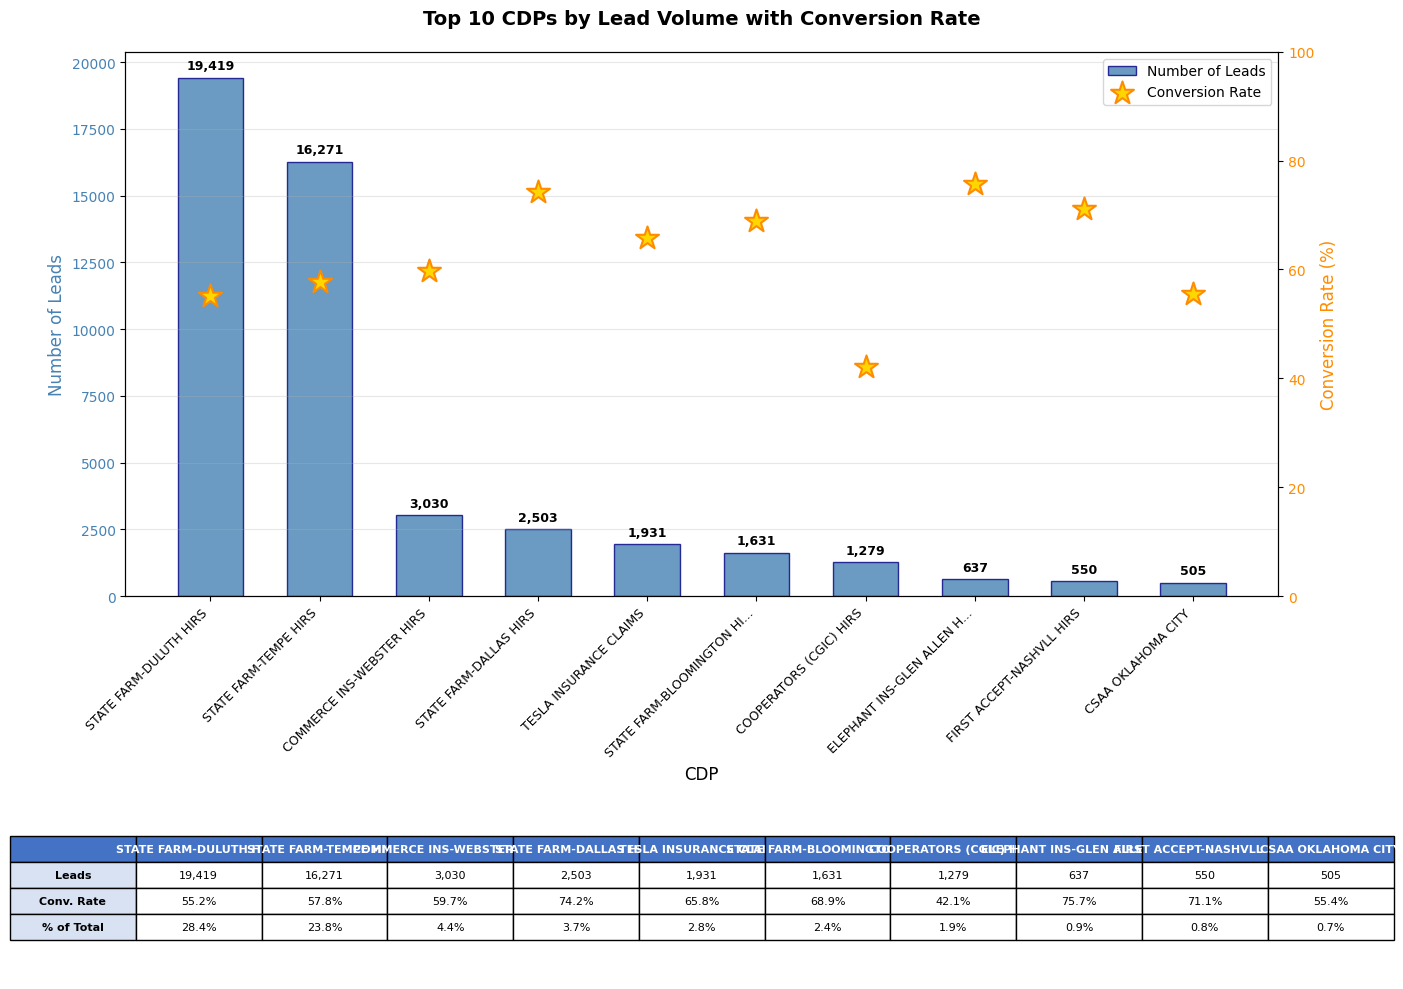


Top 10 CDPs account for 47,756 leads (69.9% of total)
Average conversion rate for top 10: 62.6%


In [5]:
# Top 10 CDPs by Lead Volume with Conversion Rate
top_10_cdps = cdp_stats.nlargest(10, 'total_reservations').copy()

# Calculate percentage of total leads
total_leads = cdp_stats['total_reservations'].sum()
top_10_cdps['pct_of_total_leads'] = (top_10_cdps['total_reservations'] / total_leads * 100)

# Shorten CDP names for display
top_10_cdps['CDP_SHORT'] = top_10_cdps['CDP NAME'].apply(
    lambda x: x[:25] + '...' if len(str(x)) > 25 else x
)

# Create figure with bar chart and data table
fig, (ax1, ax_table) = plt.subplots(2, 1, figsize=(14, 10), 
                                      gridspec_kw={'height_ratios': [3, 1]})

# Bar positions
x = range(len(top_10_cdps))
bar_width = 0.6

# Primary axis: Number of leads (bars)
bars = ax1.bar(x, top_10_cdps['total_reservations'], width=bar_width, 
               color='steelblue', alpha=0.8, label='Number of Leads', edgecolor='navy')

ax1.set_xlabel('CDP', fontsize=12)
ax1.set_ylabel('Number of Leads', fontsize=12, color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_xticks(x)
ax1.set_xticklabels(top_10_cdps['CDP_SHORT'], rotation=45, ha='right', fontsize=9)

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, top_10_cdps['total_reservations'])):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200, 
             f'{val:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Secondary axis: Conversion rate (stars)
ax2 = ax1.twinx()
ax2.scatter(x, top_10_cdps['conversion_rate'], marker='*', s=300, 
            color='gold', edgecolors='darkorange', linewidth=1.5, 
            label='Conversion Rate', zorder=5)

ax2.set_ylabel('Conversion Rate (%)', fontsize=12, color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')
ax2.set_ylim(0, 100)

# Title
ax1.set_title('Top 10 CDPs by Lead Volume with Conversion Rate', fontsize=14, fontweight='bold', pad=20)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

ax1.grid(axis='y', alpha=0.3)

# Data table below the chart
ax_table.axis('off')

# Prepare table data
table_data = [
    ['Leads'] + [f'{v:,.0f}' for v in top_10_cdps['total_reservations']],
    ['Conv. Rate'] + [f'{v:.1f}%' for v in top_10_cdps['conversion_rate']],
    ['% of Total'] + [f'{v:.1f}%' for v in top_10_cdps['pct_of_total_leads']]
]

# Column labels (shortened CDP names)
col_labels = [''] + list(top_10_cdps['CDP_SHORT'])

table = ax_table.table(
    cellText=table_data,
    colLabels=col_labels,
    loc='center',
    cellLoc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1.2, 1.5)

# Style header row
for j in range(len(col_labels)):
    table[(0, j)].set_facecolor('#4472C4')
    table[(0, j)].set_text_props(color='white', fontweight='bold')
    
# Style row labels
for i in range(1, 4):
    table[(i, 0)].set_facecolor('#D9E2F3')
    table[(i, 0)].set_text_props(fontweight='bold')

plt.tight_layout()
plt.show()

# Print summary
print(f"\nTop 10 CDPs account for {top_10_cdps['total_reservations'].sum():,} leads ({top_10_cdps['pct_of_total_leads'].sum():.1f}% of total)")
print(f"Average conversion rate for top 10: {top_10_cdps['conversion_rate'].mean():.1f}%")

In [6]:
# Calculate correlations for all metrics
correlations = {
    '% Under 30min': cdp_stats_filtered['pct_under_30min'].corr(cdp_stats_filtered['conversion_rate']),
    '% Under 1hr': cdp_stats_filtered['pct_under_1hr'].corr(cdp_stats_filtered['conversion_rate']),
    '% Counter': cdp_stats_filtered['pct_counter'].corr(cdp_stats_filtered['conversion_rate']),
    '% No Contact': cdp_stats_filtered['pct_no_contact'].corr(cdp_stats_filtered['conversion_rate'])
}

print("Correlations with Conversion Rate (CDP Level):")
for metric, corr in correlations.items():
    print(f"  {metric}: {corr:+.3f}")

Correlations with Conversion Rate (CDP Level):
  % Under 30min: +0.367
  % Under 1hr: +0.378
  % Counter: +0.089
  % No Contact: -0.031


## Chart 1: Conversion Rate vs. % Under 30 Minutes Contact

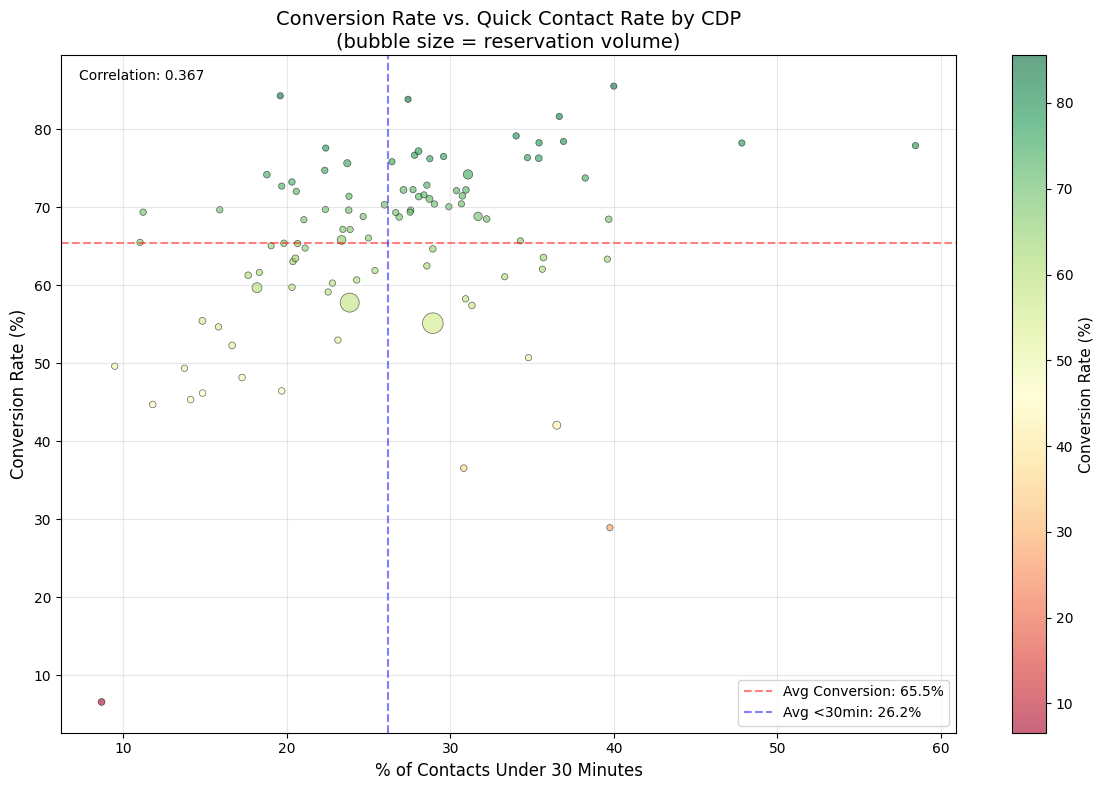

In [7]:
# Chart 1: Conversion Rate vs. % Under 30 Minutes
fig, ax = plt.subplots(figsize=(12, 8))

sizes = cdp_stats_filtered['total_reservations'] / cdp_stats_filtered['total_reservations'].max() * 200 + 20

scatter = ax.scatter(
    cdp_stats_filtered['pct_under_30min'],
    cdp_stats_filtered['conversion_rate'],
    s=sizes,
    alpha=0.6,
    c=cdp_stats_filtered['conversion_rate'],
    cmap='RdYlGn',
    edgecolors='black',
    linewidth=0.5
)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Conversion Rate (%)', fontsize=11)

ax.set_xlabel('% of Contacts Under 30 Minutes', fontsize=12)
ax.set_ylabel('Conversion Rate (%)', fontsize=12)
ax.set_title('Conversion Rate vs. Quick Contact Rate by CDP\n(bubble size = reservation volume)', fontsize=14)

ax.grid(True, alpha=0.3)

avg_conversion = cdp_stats_filtered['conversion_rate'].mean()
avg_under30 = cdp_stats_filtered['pct_under_30min'].mean()
ax.axhline(y=avg_conversion, color='red', linestyle='--', alpha=0.5, label=f'Avg Conversion: {avg_conversion:.1f}%')
ax.axvline(x=avg_under30, color='blue', linestyle='--', alpha=0.5, label=f'Avg <30min: {avg_under30:.1f}%')
ax.legend(loc='lower right')

corr = cdp_stats_filtered['pct_under_30min'].corr(cdp_stats_filtered['conversion_rate'])
ax.text(0.02, 0.98, f'Correlation: {corr:.3f}', transform=ax.transAxes, fontsize=10, verticalalignment='top')

plt.tight_layout()
plt.show()

## Chart 2: Conversion Rate vs. % Counter Contact

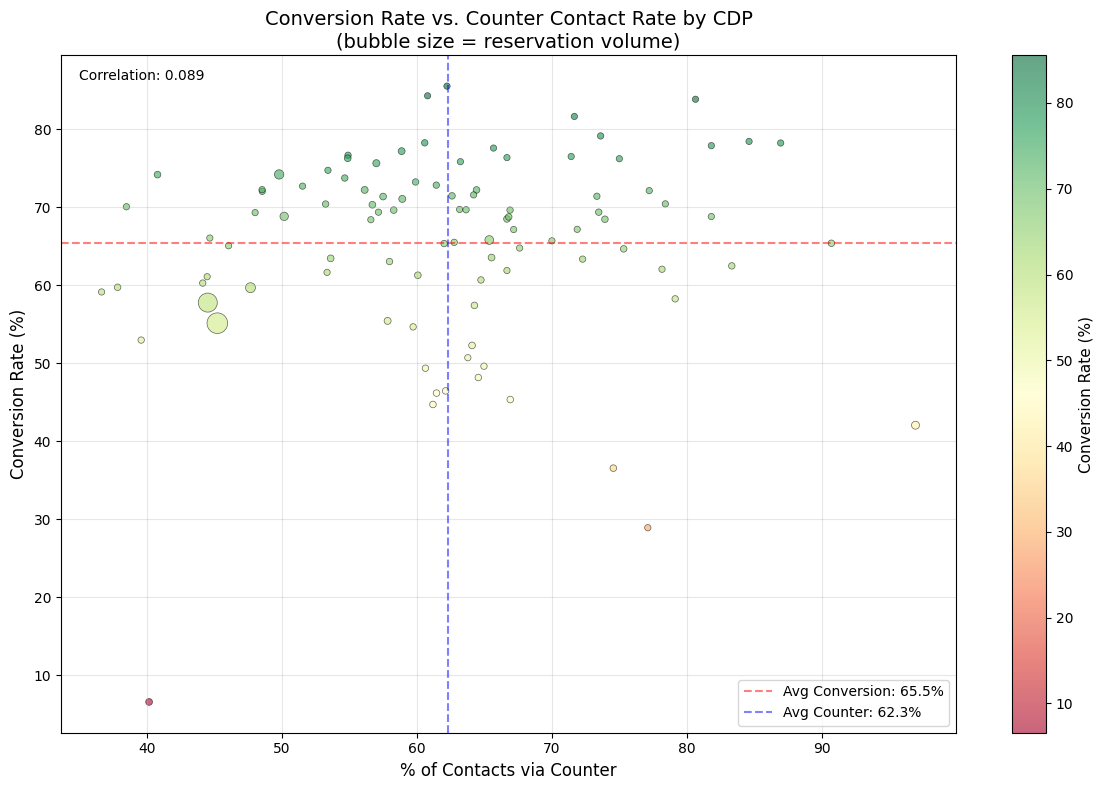

In [8]:
# Chart 2: Conversion Rate vs. % Counter
fig, ax = plt.subplots(figsize=(12, 8))

sizes = cdp_stats_filtered['total_reservations'] / cdp_stats_filtered['total_reservations'].max() * 200 + 20

scatter = ax.scatter(
    cdp_stats_filtered['pct_counter'],
    cdp_stats_filtered['conversion_rate'],
    s=sizes,
    alpha=0.6,
    c=cdp_stats_filtered['conversion_rate'],
    cmap='RdYlGn',
    edgecolors='black',
    linewidth=0.5
)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Conversion Rate (%)', fontsize=11)

ax.set_xlabel('% of Contacts via Counter', fontsize=12)
ax.set_ylabel('Conversion Rate (%)', fontsize=12)
ax.set_title('Conversion Rate vs. Counter Contact Rate by CDP\n(bubble size = reservation volume)', fontsize=14)

ax.grid(True, alpha=0.3)

avg_counter = cdp_stats_filtered['pct_counter'].mean()
ax.axhline(y=avg_conversion, color='red', linestyle='--', alpha=0.5, label=f'Avg Conversion: {avg_conversion:.1f}%')
ax.axvline(x=avg_counter, color='blue', linestyle='--', alpha=0.5, label=f'Avg Counter: {avg_counter:.1f}%')
ax.legend(loc='lower right')

corr = cdp_stats_filtered['pct_counter'].corr(cdp_stats_filtered['conversion_rate'])
ax.text(0.02, 0.98, f'Correlation: {corr:.3f}', transform=ax.transAxes, fontsize=10, verticalalignment='top')

plt.tight_layout()
plt.show()

## Chart 3: Conversion Rate vs. % No Contact

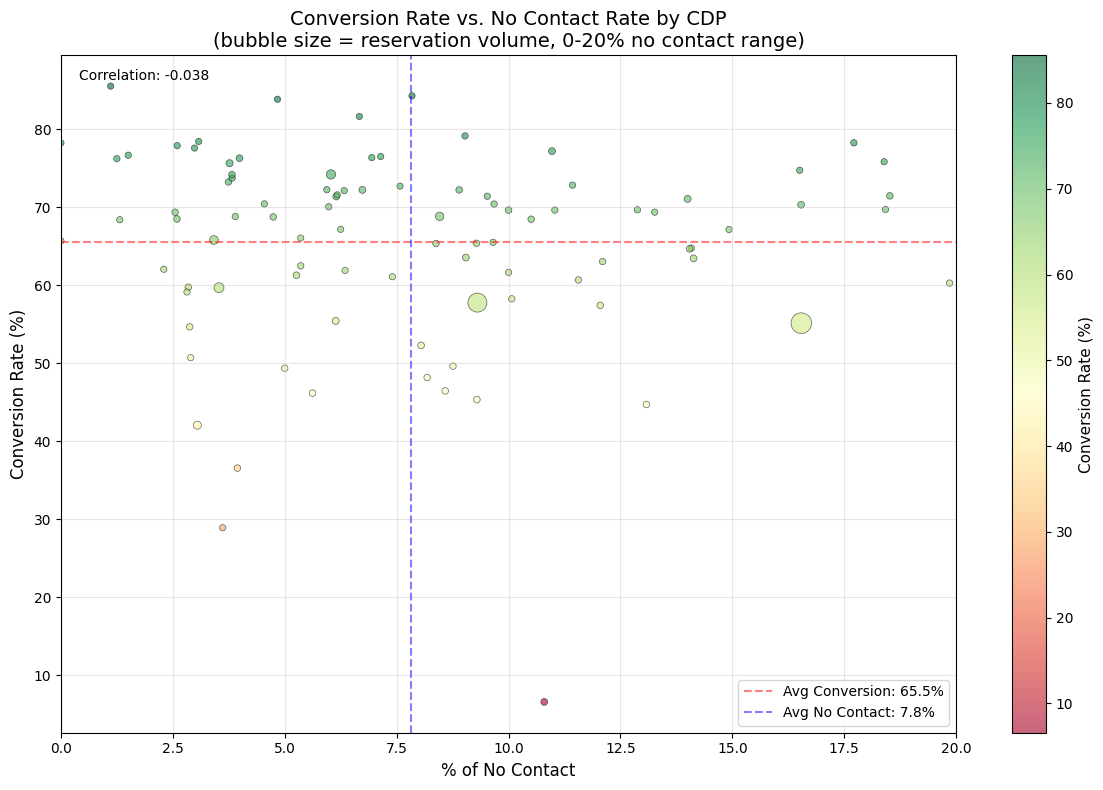

Showing 93 CDPs with <=20% no contact (excluded 5 CDPs)


In [9]:
# Chart 3: Conversion Rate vs. % No Contact (0-20% range)
fig, ax = plt.subplots(figsize=(12, 8))

# Filter to CDPs with <=20% no contact
no_contact_filtered = cdp_stats_filtered[cdp_stats_filtered['pct_no_contact'] <= 20].copy()

sizes = no_contact_filtered['total_reservations'] / no_contact_filtered['total_reservations'].max() * 200 + 20

scatter = ax.scatter(
    no_contact_filtered['pct_no_contact'],
    no_contact_filtered['conversion_rate'],
    s=sizes,
    alpha=0.6,
    c=no_contact_filtered['conversion_rate'],
    cmap='RdYlGn',
    edgecolors='black',
    linewidth=0.5
)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Conversion Rate (%)', fontsize=11)

ax.set_xlabel('% of No Contact', fontsize=12)
ax.set_ylabel('Conversion Rate (%)', fontsize=12)
ax.set_title('Conversion Rate vs. No Contact Rate by CDP\n(bubble size = reservation volume, 0-20% no contact range)', fontsize=14)

ax.set_xlim(0, 20)

ax.grid(True, alpha=0.3)

avg_no_contact = no_contact_filtered['pct_no_contact'].mean()
avg_conv_no_contact = no_contact_filtered['conversion_rate'].mean()
ax.axhline(y=avg_conv_no_contact, color='red', linestyle='--', alpha=0.5, label=f'Avg Conversion: {avg_conv_no_contact:.1f}%')
ax.axvline(x=avg_no_contact, color='blue', linestyle='--', alpha=0.5, label=f'Avg No Contact: {avg_no_contact:.1f}%')
ax.legend(loc='lower right')

corr = no_contact_filtered['pct_no_contact'].corr(no_contact_filtered['conversion_rate'])
ax.text(0.02, 0.98, f'Correlation: {corr:.3f}', transform=ax.transAxes, fontsize=10, verticalalignment='top')

plt.tight_layout()
plt.show()

print(f"Showing {len(no_contact_filtered)} CDPs with <=20% no contact (excluded {len(cdp_stats_filtered) - len(no_contact_filtered)} CDPs)")

## Chart 4: Conversion Rate vs. % Under 1 Hour Contact

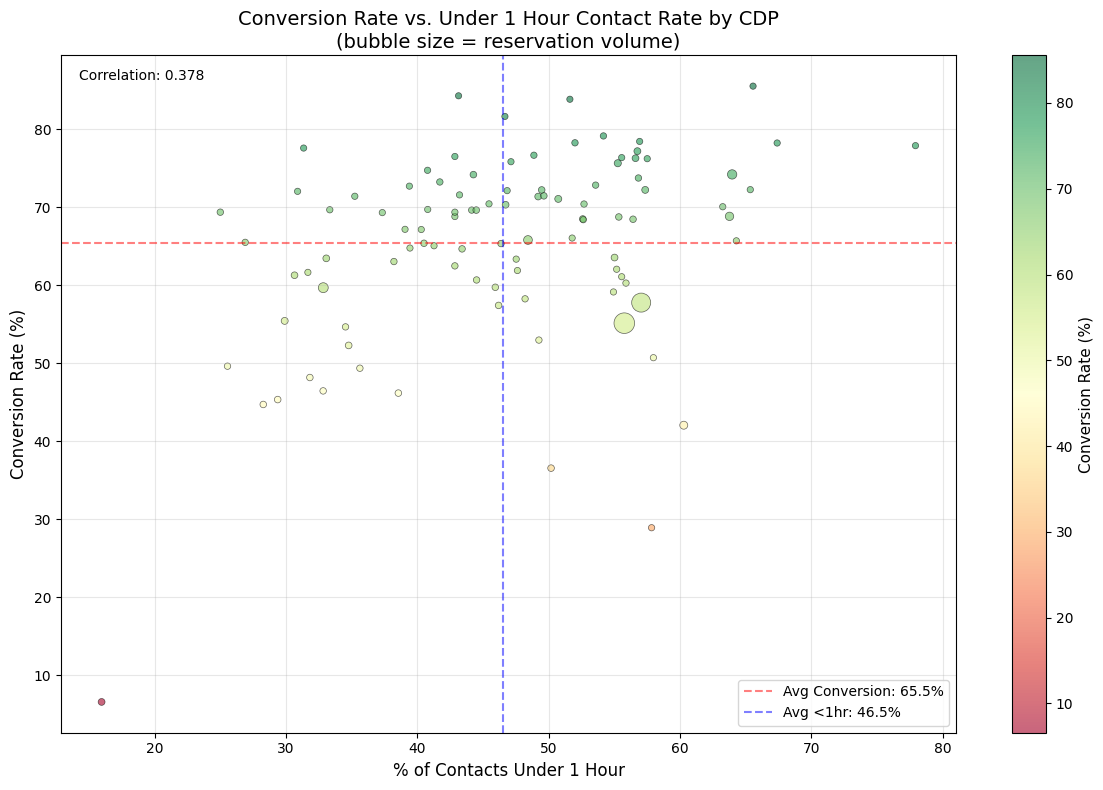

In [10]:
# Chart 4: Conversion Rate vs. % Under 1 Hour
fig, ax = plt.subplots(figsize=(12, 8))

sizes = cdp_stats_filtered['total_reservations'] / cdp_stats_filtered['total_reservations'].max() * 200 + 20

scatter = ax.scatter(
    cdp_stats_filtered['pct_under_1hr'],
    cdp_stats_filtered['conversion_rate'],
    s=sizes,
    alpha=0.6,
    c=cdp_stats_filtered['conversion_rate'],
    cmap='RdYlGn',
    edgecolors='black',
    linewidth=0.5
)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Conversion Rate (%)', fontsize=11)

ax.set_xlabel('% of Contacts Under 1 Hour', fontsize=12)
ax.set_ylabel('Conversion Rate (%)', fontsize=12)
ax.set_title('Conversion Rate vs. Under 1 Hour Contact Rate by CDP\n(bubble size = reservation volume)', fontsize=14)

ax.grid(True, alpha=0.3)

avg_under_1hr = cdp_stats_filtered['pct_under_1hr'].mean()
ax.axhline(y=avg_conversion, color='red', linestyle='--', alpha=0.5, label=f'Avg Conversion: {avg_conversion:.1f}%')
ax.axvline(x=avg_under_1hr, color='blue', linestyle='--', alpha=0.5, label=f'Avg <1hr: {avg_under_1hr:.1f}%')
ax.legend(loc='lower right')

corr = cdp_stats_filtered['pct_under_1hr'].corr(cdp_stats_filtered['conversion_rate'])
ax.text(0.02, 0.98, f'Correlation: {corr:.3f}', transform=ax.transAxes, fontsize=10, verticalalignment='top')

plt.tight_layout()
plt.show()

## Summary: Top 15 CDPs by Volume

In [11]:
# Top 15 CDPs by volume with all metrics
print("Top 15 CDPs by Volume:")
cdp_stats_filtered.nlargest(15, 'total_reservations')[
    ['CDP NAME', 'total_reservations', 'conversion_rate', 
     'pct_under_30min', 'pct_under_1hr', 'pct_counter', 'pct_no_contact']
].round(1)

Top 15 CDPs by Volume:


,CDP NAME,total_reservations,conversion_rate,pct_under_30min,pct_under_1hr,pct_counter,pct_no_contact
592,STATE FARM-DULUTH HIRS,19419,55.2,28.9,55.8,45.2,16.5
598,STATE FARM-TEMPE HIRS,16271,57.8,23.9,57.0,44.5,9.3
116,COMMERCE INS-WEBSTER HIRS,3030,59.7,18.2,32.8,47.7,3.5
591,STATE FARM-DALLAS HIRS,2503,74.2,31.1,64.0,49.8,6.0
604,TESLA INSURANCE CLAIMS,1931,65.8,23.4,48.4,65.4,3.4
587,STATE FARM-BLOOMINGTON HIRS,1631,68.9,31.7,63.8,50.2,8.5
120,COOPERATORS (CGIC) HIRS,1279,42.1,36.5,60.3,97.0,3.0
136,ELEPHANT INS-GLEN ALLEN HIRS,637,75.7,23.7,55.3,57.0,3.8
191,FIRST ACCEPT-NASHVLL HIRS,550,71.1,28.7,50.7,58.9,14.0
127,CSAA OKLAHOMA CITY,505,55.4,14.9,29.9,57.8,6.1
